In [34]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 1. 读取数据
data = pd.read_csv('/Users/hezixin/Downloads/2023上机程序/data/trial.csv')

In [15]:
data.head()

,Sector_score,LOCATION_ID,PARA_A,SCORE_A,PARA_B,SCORE_B,TOTAL,numbers,Marks,Money_Value,MONEY_Marks,District,Loss,LOSS_SCORE,History,History_score,Score,Risk
0,3.89,23,4.18,6,2.50,2,6.68,5.0,2,3.38,2,2,0,2,0,2,2.4,1
1,3.89,6,0.00,2,4.83,2,4.83,5.0,2,0.94,2,2,0,2,0,2,2.0,0
2,3.89,6,0.51,2,0.23,2,0.74,5.0,2,0.00,2,2,0,2,0,2,2.0,0
3,3.89,6,0.00,2,10.80,6,10.80,6.0,6,11.75,6,2,0,2,0,2,4.4,1
4,3.89,6,0.00,2,0.08,2,0.08,5.0,2,0.00,2,2,0,2,0,2,2.0,0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sector_score   776 non-null    float64
 1   LOCATION_ID    776 non-null    object 
 2   PARA_A         776 non-null    float64
 3   SCORE_A        776 non-null    int64  
 4   PARA_B         776 non-null    float64
 5   SCORE_B        776 non-null    int64  
 6   TOTAL          776 non-null    float64
 7   numbers        776 non-null    float64
 8   Marks          776 non-null    int64  
 9   Money_Value    775 non-null    float64
 10  MONEY_Marks    776 non-null    int64  
 11  District       776 non-null    int64  
 12  Loss           776 non-null    int64  
 13  LOSS_SCORE     776 non-null    int64  
 14  History        776 non-null    int64  
 15  History_score  776 non-null    int64  
 16  Score          776 non-null    float64
 17  Risk           776 non-null    int64  
dtypes: float64

In [17]:
# 3. 特征描述性统计
fraud_data = data[data['Risk'] == 1]  # 假设Fraud列中1表示欺诈
non_fraud_data = data[data['Risk'] == 0]  # 假设Fraud列中0表示非欺诈

# 计算描述性统计
fraud_stats = fraud_data.describe()
non_fraud_stats = non_fraud_data.describe()

# 打印描述性统计结果
print("Fraud Class Descriptive Statistics:")
print(fraud_stats)
print("\nNon-Fraud Class Descriptive Statistics:")
print(non_fraud_stats)

Fraud Class Descriptive Statistics:
       Sector_score      PARA_A     SCORE_A       PARA_B     SCORE_B  \
count    486.000000  486.000000  486.000000   486.000000  486.000000   
mean      13.152181    3.732162    4.415638    17.094630    3.806584   
std       20.836633    6.860750    1.629649    62.464645    1.839890   
min        1.850000    0.000000    2.000000     0.000000    2.000000   
25%        2.370000    1.000000    4.000000     0.020000    2.000000   
50%        3.410000    1.710000    4.000000     1.390000    4.000000   
75%        3.890000    4.160000    6.000000    15.447500    6.000000   
max       59.850000   85.000000    6.000000  1264.630000    6.000000   

             TOTAL     numbers       Marks  Money_Value  MONEY_Marks  \
count   486.000000  486.000000  486.000000   486.000000   486.000000   
mean     20.776174    5.108025    2.378601    22.387140     3.452675   
std      63.671213    0.327687    0.988947    83.047186     1.813132   
min       0.000000    5.000

In [26]:
# 4. 特征差异性描述
# 使用t-test来比较欺诈类和非欺诈类在各个特征上的差异
t_tests = {}
for column in data.columns:
    if data[column].dtype == 'float64' or data[column].dtype == 'int64':  # 假设只有数值型特征需要比较
        t_stat, p_val = stats.ttest_ind(fraud_data[column], non_fraud_data[column], equal_var=False)
        t_tests[column] = (t_stat, p_val)

# 打印t-test结果
for column, (t_stat, p_val) in t_tests.items():
    print(f"{column}: t-stat={t_stat}, p-value={p_val}")

Sector_score: t-stat=-10.71819653727036, p-value=2.328505004134453e-24
PARA_A: t-stat=11.004210167622249, p-value=2.6013362351489674e-25
SCORE_A: t-stat=32.678037153712324, p-value=1.2104253690603537e-124
PARA_B: t-stat=5.944235333497931, p-value=5.312551233255797e-09
SCORE_B: t-stat=21.64634725506635, p-value=3.252465235496781e-73
TOTAL: t-stat=7.001605841750853, p-value=8.473380701926508e-12
numbers: t-stat=7.267448372668955, p-value=1.4746087841278759e-12
Marks: t-stat=8.43969692438408, p-value=3.696030023047039e-16
Money_Value: t-stat=nan, p-value=nan
MONEY_Marks: t-stat=17.662705329427997, p-value=2.8423242293551136e-54
District: t-stat=12.074476492418398, p-value=1.5624723417040316e-29
Loss: t-stat=4.513714685846538, p-value=8.00436930746744e-06
LOSS_SCORE: t-stat=4.6299529250736216, p-value=4.702711251387729e-06
History: t-stat=5.537819725017379, p-value=5.026831445688843e-08
History_score: t-stat=6.98946809157343, p-value=9.169525308222148e-12
Score: t-stat=29.399640818836257, 

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


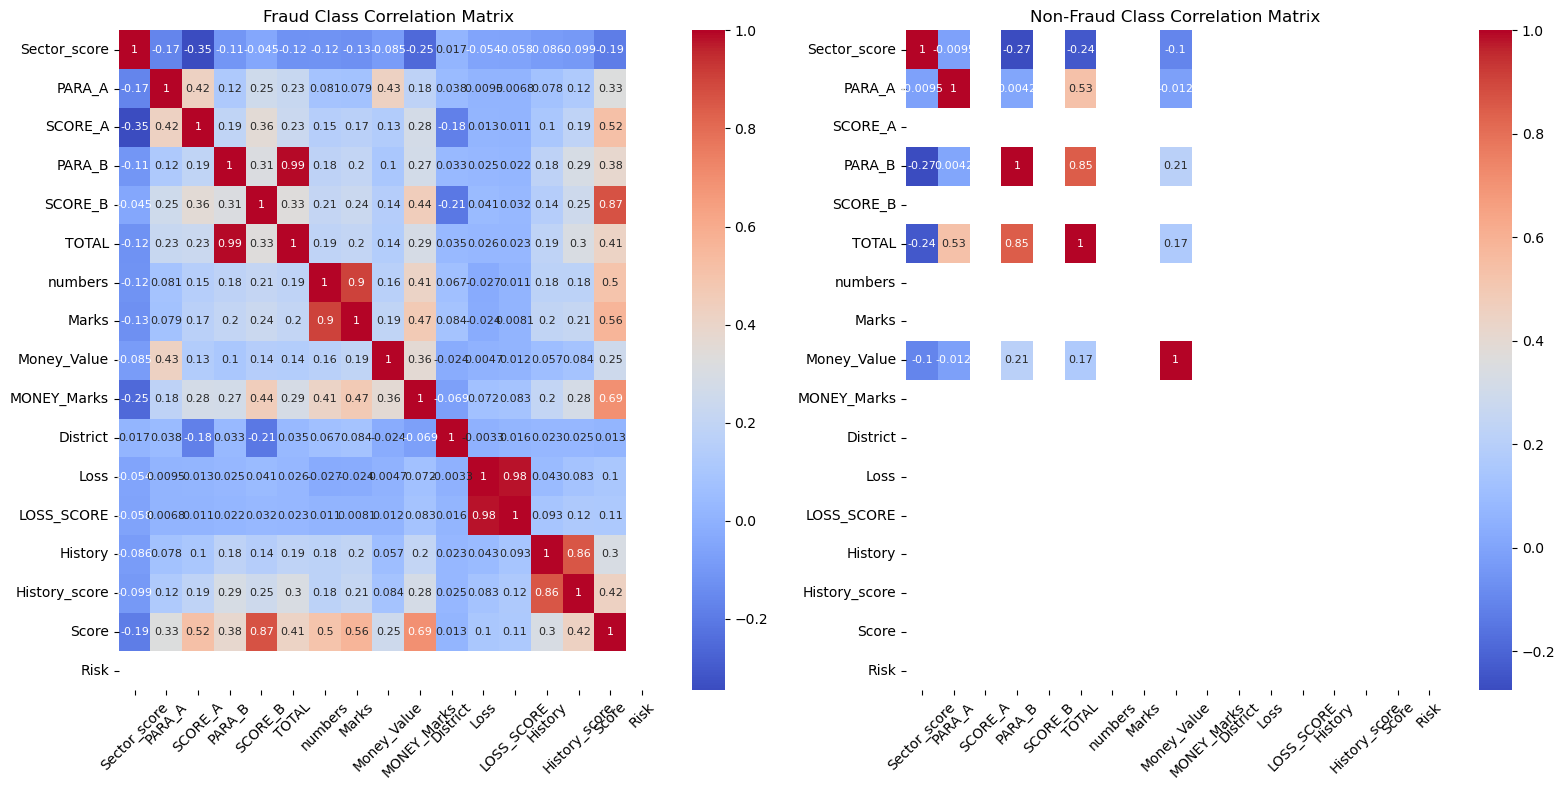

In [36]:
numerical_cols = data.select_dtypes(include=['number']).columns
fraud_correlation = fraud_data[numerical_cols].corr()
non_fraud_correlation = non_fraud_data[numerical_cols].corr()

# 5. 绘制相关矩阵图
plt.figure(figsize=(16, 8))  # 调整图的大小

# 绘制欺诈类的相关矩阵图
plt.subplot(1, 2, 1)
sns.heatmap(fraud_correlation, annot=True, cmap='coolwarm', 
            xticklabels=fraud_correlation.columns, yticklabels=fraud_correlation.columns,
            annot_kws={"size": 8})  # 调整注释字体大小
plt.title('Fraud Class Correlation Matrix')
plt.xticks(rotation=45)  # 旋转x轴标签
plt.yticks(rotation=0)

# 绘制非欺诈类的相关矩阵图
plt.subplot(1, 2, 2)
sns.heatmap(non_fraud_correlation, annot=True, cmap='coolwarm', 
            xticklabels=non_fraud_correlation.columns, yticklabels=non_fraud_correlation.columns,
            annot_kws={"size": 8})  # 调整注释字体大小
plt.title('Non-Fraud Class Correlation Matrix')
plt.xticks(rotation=45)  # 旋转x轴标签
plt.yticks(rotation=0)

plt.tight_layout()  # 自动调整子图参数, 使之填充整个图像区域
plt.show()

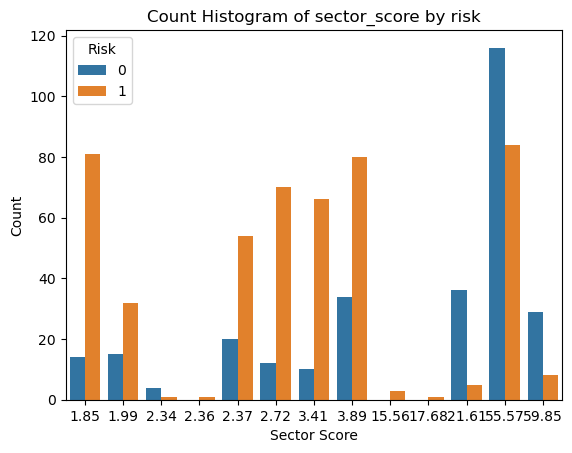

In [38]:
sns.countplot(x='Sector_score', hue='Risk', data=data)

# 添加标题和标签
plt.title('Count Histogram of sector_score by risk')
plt.xlabel('Sector Score')
plt.ylabel('Count')

# 显示图形
plt.show()

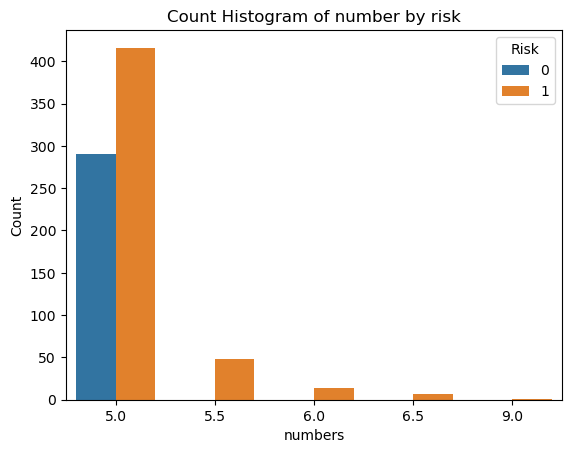

In [40]:
sns.countplot(x='numbers', hue='Risk', data=data)

# 添加标题和标签
plt.title('Count Histogram of number by risk')
plt.xlabel('numbers')
plt.ylabel('Count')

# 显示图形
plt.show()

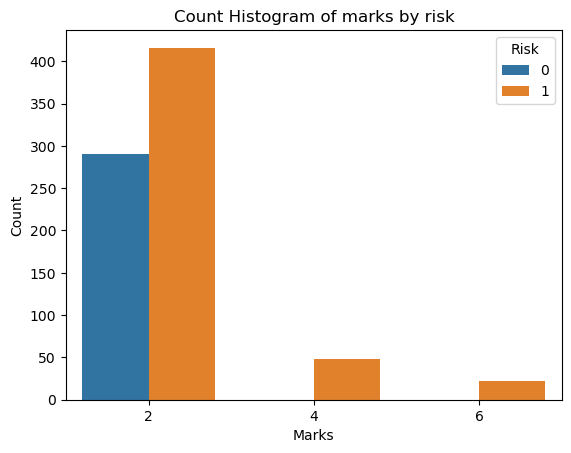

In [42]:
sns.countplot(x='Marks', hue='Risk', data=data)

# 添加标题和标签
plt.title('Count Histogram of marks by risk')
plt.xlabel('Marks')
plt.ylabel('Count')

# 显示图形
plt.show()